# QuVINE Tutorial — quantum graph embeddings inside QBioCode

This tutorial mirrors the [QProfiler tutorial](../QProfiler/example_qprofiler.ipynb), but for
**QuVINE** (Quantum View-based Network Embeddings), now vendored into QBioCode as an in-tree app.

## What is QuVINE (in QBioCode)?

QProfiler characterizes a **tabular dataset** (samples × features) and benchmarks ML models on it.
QuVINE works on a different modality — a **graph** — and produces **node embeddings**:

- **`qbiocode.apps.quvine.embed`** — turn a `networkx.Graph` into a node-embedding matrix using
  classical or *quantum* walks (RWR / CTQW / DTQW) and a registry of comparison methods
  (node2vec, NetMF, APPNP, GAT, GraphGPS, quantum-calibrated filters, …).
- **`qbiocode.evaluate_graph`** — the graph analogue of QProfiler's `evaluate(df, y)`: a one-row
  summary of ~80 graph-complexity metrics (spectral, topological, structural).

QuVINE ships inside QBioCode, behind the optional `[quvine]` extra (see **Install** below).

### What this notebook does

1. Generate **three graphs** of increasing difficulty (small, so it runs quickly).
2. Embed each with **12 methods** and score a **node-classification** task over **5 iterations**.
3. Summarize each graph's **complexity** (spectral gap, IPR, spectral degeneracy, …).
4. **Correlate** those complexity measures with macro-F1 and visualize the relationships.

---

**Install.** QuVINE ships behind an optional extra, so a plain `pip install qbiocode`
does *not* pull its dependencies (gensim, hiperwalk, node2vec, torch-geometric,
python-louvain, ripser, omegaconf). Install it with:

```bash
pip install "qbiocode[quvine]"
```

Calling a `quvine_*` method without the extra raises an error naming the missing
package and this exact command, rather than a bare `ModuleNotFoundError`.


## 1. Setup and imports

In [1]:
import os, warnings
warnings.filterwarnings("ignore")

# Pin OpenMP to a single thread BEFORE importing qbiocode. torch, xgboost and
# qiskit-aer each vendor their own copy of libomp, and on macOS whichever one
# initialises second crashes the process with a bare SIGSEGV -- no traceback,
# just a dead kernel -- the first time it opens a parallel region. The
# torch-backed methods below (appnp, gat_*, graphgps_*) hit it every time.
# See qbiocode/utils/_openmp.py for the full analysis.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from qbiocode.apps.quvine import embed, list_methods
from qbiocode import evaluate_graph
from qbiocode.apps.quvine.evaluation.classification import evaluate_node_classification

sns.set_style("whitegrid")
sns.set_context("notebook")

print("total QuVINE methods available:", len(list_methods()))

total QuVINE methods available: 83


## 2. Generate three graphs

We build three **stochastic block models (SBMs)** with 3 planted communities of 20 nodes each
(60 nodes total). They differ only in the *between-community* edge probability `p_out`: as `p_out`
grows the communities blur together, so the graphs go from **easy → medium → hard** for a
community-based node-classification task.

Because the communities are *planted*, we use block membership as the **ground-truth labels** — no
label inference needed. QuVINE's walk corpus needs **string** node ids, so we relabel to `str`.

In [2]:
def make_sbm(p_out, seed=1, sizes=(50, 50, 50), p_in=0.28):
    k = len(sizes)
    probs = [[p_in if i == j else p_out for j in range(k)] for i in range(k)]
    G = nx.stochastic_block_model(list(sizes), probs, seed=seed)
    labels = {n: G.nodes[n]["block"] for n in G.nodes}          # planted community = label
    G = nx.relabel_nodes(G, {n: str(n) for n in G.nodes})
    labels = {str(n): b for n, b in labels.items()}
    return G, labels

# Same seed + p_in for all three; only p_out (between-community density) changes,
# so the difficulty gradient is a controlled comparison. All three are connected.
graphs = {
    "sbm_easy":   make_sbm(p_out=0.04),
    "sbm_medium": make_sbm(p_out=0.08),
    "sbm_hard":   make_sbm(p_out=0.14),
}

for name, (G, labels) in graphs.items():
    print(f"{name:11s} nodes={G.number_of_nodes():3d}  edges={G.number_of_edges():4d}  "
          f"classes={len(set(labels.values()))}  connected={nx.is_connected(G)}")

sbm_easy    nodes=150  edges=1368  classes=3  connected=True
sbm_medium  nodes=150  edges=1662  classes=3  connected=True
sbm_hard    nodes=150  edges=2040  classes=3  connected=True


## 3. Choose task and methods

**Task:** node classification (predict each node's community from its embedding).

**Methods (12):** three QuVINE walks, two quantum-calibrated spectral *filters*, two quantum-calibrated
*GAT* variants, two quantum-calibrated *GraphGPS* variants, and three classical baselines.

In [3]:
methods = [
    # QuVINE SGNS walks
    "quvine_rwr", "quvine_ctqw", "quvine_dtqw",
    # quantum-calibrated spectral filters
    "filter_rwr_heat", "filter_ctqw_heat",
    # quantum-calibrated GAT
    "gat_rwr_poly", "gat_ctqw_poly",
    # quantum-calibrated GraphGPS
    "graphgps_rwr_heat", "graphgps_ctqw_heat",
    # classical baselines
    "node2vec", "netmf", "appnp",
]
N_ITER = 5

# Small/fast embedding settings -- drop these overrides for full-quality runs.
fast = {
    "train":  {"embedding_dim": 32, "epochs": 10, "workers": 1},
    "walks":  {"num_walks": 8, "walk_length": 8},
    "views":  {"num_views": 4},
}
print(f"{len(methods)} methods x {len(graphs)} graphs x {N_ITER} iters = "
      f"{len(methods) * len(graphs) * N_ITER} embedding runs")

12 methods x 3 graphs x 5 iters = 180 embedding runs


## 4. Run the benchmark

For every (graph, method, iteration) we embed the graph and evaluate node classification, recording
**macro-F1** and accuracy. Each iteration uses a different seed so embeddings and the train/test split
vary — giving us a spread to average over.

In [4]:
records = []
for gname, (G, labels) in graphs.items():
    node_list = list(G.nodes)
    for method in methods:
        for it in range(N_ITER):
            try:
                res = embed(G, method, overrides=fast, base_seed=42 + it)
                nc = evaluate_node_classification(
                    res.embedding, labels, res.node_order,
                    classifier="logistic", random_state=42 + it,
                )
                records.append({
                    "graph": gname, "method": method, "iter": it,
                    "macro_f1": nc.get("f1_macro"), "accuracy": nc.get("accuracy"),
                    "dim": res.dim, "embed_time_s": round(res.execution_time, 3),
                })
            except Exception as e:
                records.append({"graph": gname, "method": method, "iter": it,
                                "macro_f1": np.nan, "accuracy": np.nan, "error": str(e)[:80]})
    print(f"  done: {gname}")

results = pd.DataFrame(records)
print("collected", len(results), "rows")
results.head()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Computing transition probabilities:   0%|          | 0/150 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 150/150 [00:00<00:00, 3773.96it/s]

<env>/lib/python3.12/site-packages/node2vec/edges.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
<env>/lib/python3.12/site-packages/node2vec/edges.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
<env>/lib/python3.12/site-packages/node2vec/edges.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
<env>/lib/python3.12/site-packages/no

Generating walks (CPU: 8): 100%|██████████| 1/1 [00:00<00:00, 103.81it/s]


...


Generating walks (CPU: 4): 100%|██████████| 1/1 [00:00<00:00, 102.02it/s]


Generating walks (CPU: 8):   0%|          | 0/1 [00:00<?, ?it/s]

Generating walks (CPU: 8): 100%|██████████| 1/1 [00:00<00:00, 107.45it/s]


  done: sbm_hard
collected 180 rows


,graph,method,iter,macro_f1,accuracy,dim,embed_time_s
0,sbm_easy,quvine_rwr,0,0.932542,0.933333,32,2.161
1,sbm_easy,quvine_rwr,1,1.000000,1.000000,32,2.160
2,sbm_easy,quvine_rwr,2,0.909370,0.911111,32,2.046
3,sbm_easy,quvine_rwr,3,0.977753,0.977778,32,2.019
4,sbm_easy,quvine_rwr,4,0.977753,0.977778,32,2.080


### Per-method summary (mean over graphs & iterations)

In [5]:
summary = (results.groupby("method")
           .agg(macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
                accuracy_mean=("accuracy", "mean"),
                embed_time_s=("embed_time_s", "mean"))
           .sort_values("macro_f1_mean", ascending=False)
           .round(3))
summary

,macro_f1_mean,macro_f1_std,accuracy_mean,embed_time_s
method,,,,
netmf,0.923,0.095,0.923,0.014
filter_ctqw_heat,0.895,0.145,0.896,0.194
graphgps_ctqw_heat,0.873,0.166,0.876,1.163
gat_ctqw_poly,0.863,0.161,0.867,1.440
graphgps_rwr_heat,0.863,0.180,0.864,1.144
gat_rwr_poly,0.862,0.148,0.864,0.967
filter_rwr_heat,0.860,0.148,0.861,0.179
appnp,0.698,0.204,0.704,0.160
quvine_rwr,0.675,0.245,0.680,2.179


### Macro-F1 by method and graph difficulty

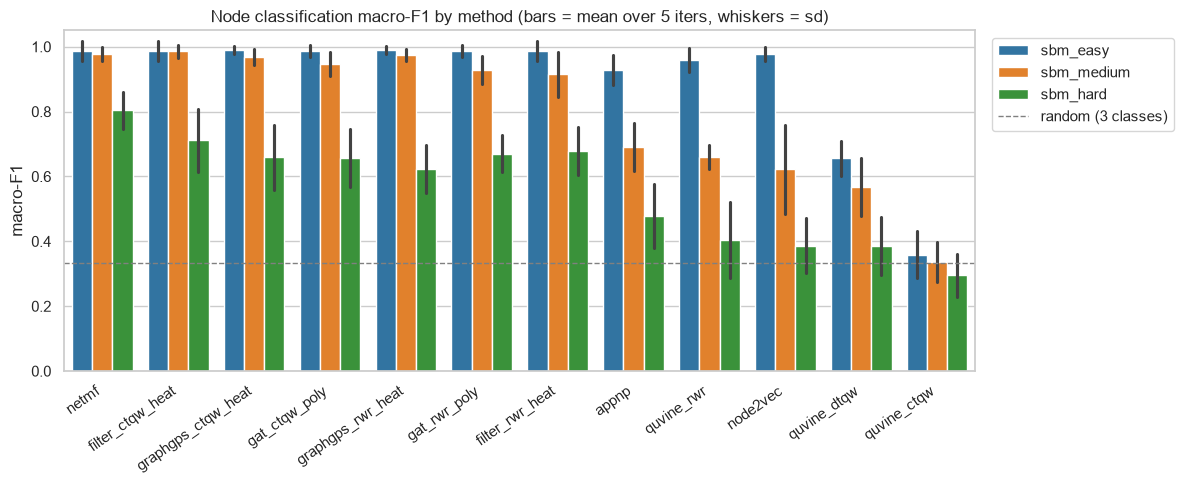

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
order = summary.index.tolist()
sns.barplot(data=results, x="method", y="macro_f1", hue="graph",
            order=order, hue_order=list(graphs), errorbar="sd", ax=ax)
ax.set_title("Node classification macro-F1 by method (bars = mean over 5 iters, whiskers = sd)")
ax.set_xlabel(""); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.05)
ax.axhline(1/3, ls="--", c="gray", lw=1, label="random (3 classes)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 5. Graph complexity metrics

`evaluate_graph` returns ~80 metrics per graph. We pull a curated set spanning connectivity,
**spectral localization (IPR)**, **spectral degeneracy**, entropy, and community structure — the
kinds of measures hypothesized to track how hard a graph is to embed/classify.

In [7]:
complexity_cols = [
    "spectral_gap", "normalized_spectral_gap", "algebraic_connectivity",
    "spectral_degeneracy_fraction",                       # spectral degeneracy
    "inverse_participation_ratio", "ipr_low_mean", "ipr_high_mean",   # IPR / localization
    "von_neumann_entropy", "spectral_entropy",
    "modularity", "transitivity", "degree_gini", "avg_degree", "density",
]

rows = []
for gname, (G, _labels) in graphs.items():
    ev = evaluate_graph(G, name=gname)
    row = {"graph": gname}
    row.update({c: float(ev[c].iloc[0]) for c in complexity_cols if c in ev.columns})
    rows.append(row)

complexity = pd.DataFrame(rows).set_index("graph")
complexity.T.round(4)

graph,sbm_easy,sbm_medium,sbm_hard
spectral_gap,0.2887,0.4719,0.6253
normalized_spectral_gap,0.2887,0.4719,0.6253
algebraic_connectivity,5.2381,9.2314,12.8869
spectral_degeneracy_fraction,0.0000,0.0000,0.0000
inverse_participation_ratio,0.0194,0.0198,0.0195
ipr_low_mean,0.0195,0.0190,0.0194
ipr_high_mean,0.0194,0.0205,0.0197
von_neumann_entropy,7.1532,7.1608,7.1715
spectral_entropy,4.9788,4.9844,4.9888
modularity,0.4344,0.2780,0.1369


### Complexity fingerprint across the three graphs

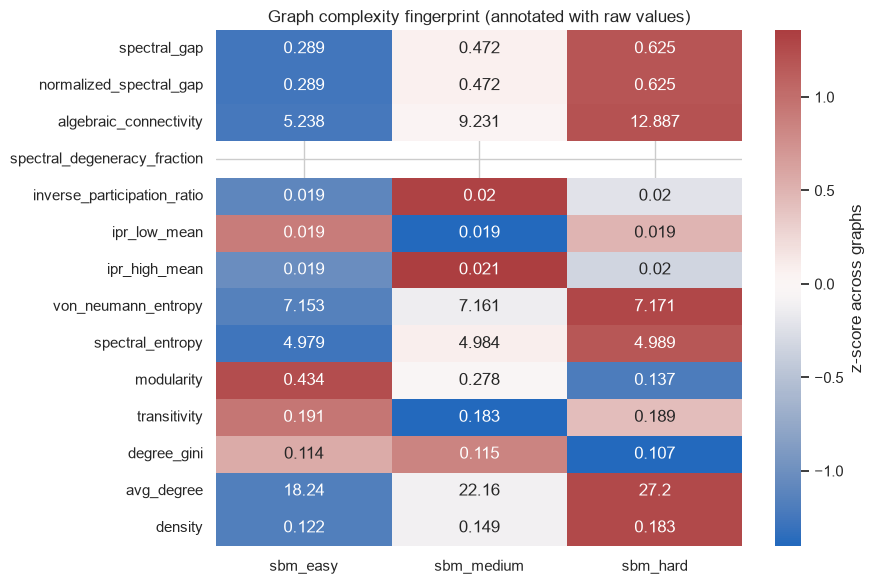

In [8]:
# z-score each metric across the 3 graphs so they are visually comparable on one heatmap.
z = complexity.copy()
z = (z - z.mean()) / z.std(ddof=0)
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(z.T, annot=complexity.T.round(3), fmt="", cmap="vlag", center=0,
            cbar_kws={"label": "z-score across graphs"}, ax=ax)
ax.set_title("Graph complexity fingerprint (annotated with raw values)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

## 6. Correlate complexity with node-classification performance

We merge each graph's complexity metrics onto every result row and compute the **Spearman
correlation** between each complexity metric and macro-F1 across all `(graph, method, iteration)`
runs. A positive value means "higher metric ⟶ easier classification".

> With only three distinct graphs the complexity axis takes three values, so treat these
> correlations as **illustrative of the trend** (harder graphs ⟶ lower F1) rather than precise
> effect sizes.

In [9]:
from scipy.stats import spearmanr

merged = results.merge(complexity.reset_index(), on="graph", how="left").dropna(subset=["macro_f1"])

# Drop metrics that are constant across the three graphs (no variance -> undefined correlation).
constant = [c for c in complexity_cols if merged[c].nunique() <= 1]
active = [c for c in complexity_cols if c not in constant]
if constant:
    print("constant across these graphs (skipped):", constant)

corr = []
for c in active:
    rho, pval = spearmanr(merged[c], merged["macro_f1"])
    corr.append({"metric": c, "spearman_rho": rho, "p_value": pval})
corr_df = pd.DataFrame(corr).sort_values("spearman_rho", ascending=False).reset_index(drop=True)
corr_df.round(3)

constant across these graphs (skipped): ['spectral_degeneracy_fraction']


,metric,spearman_rho,p_value
0,modularity,0.619,0.000
1,degree_gini,0.372,0.000
2,ipr_low_mean,0.248,0.001
3,transitivity,0.248,0.001
4,inverse_participation_ratio,-0.248,0.001
5,ipr_high_mean,-0.248,0.001
6,spectral_gap,-0.619,0.000
7,normalized_spectral_gap,-0.619,0.000
8,algebraic_connectivity,-0.619,0.000
9,von_neumann_entropy,-0.619,0.000


### Correlation bar chart

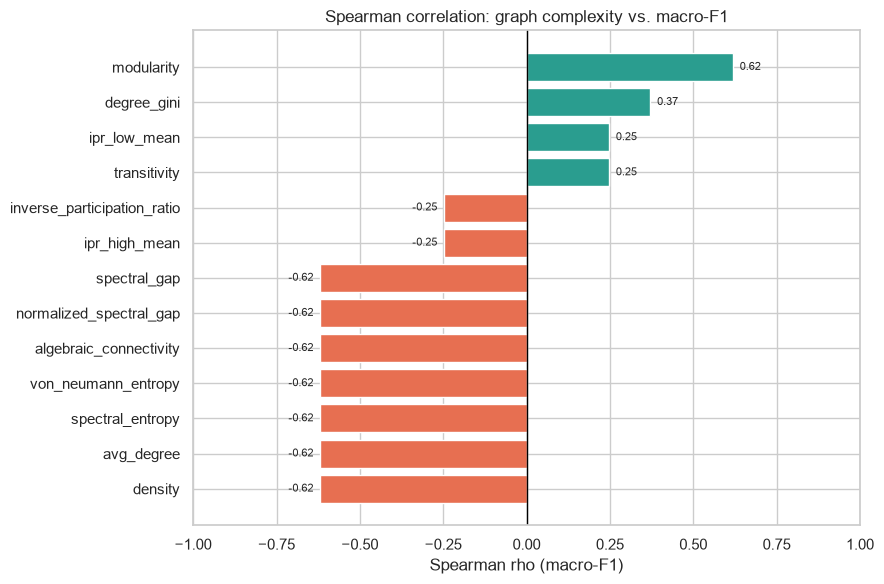

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in corr_df["spearman_rho"]]
ax.barh(corr_df["metric"], corr_df["spearman_rho"], color=colors)
ax.invert_yaxis()                                   # largest positive on top
ax.axvline(0, c="black", lw=1)
ax.set_title("Spearman correlation: graph complexity vs. macro-F1")
ax.set_xlabel("Spearman rho (macro-F1)"); ax.set_xlim(-1, 1)
for y, v in enumerate(corr_df["spearman_rho"]):
    ax.text(v + (0.02 if v >= 0 else -0.02), y, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

### How performance tracks two key metrics

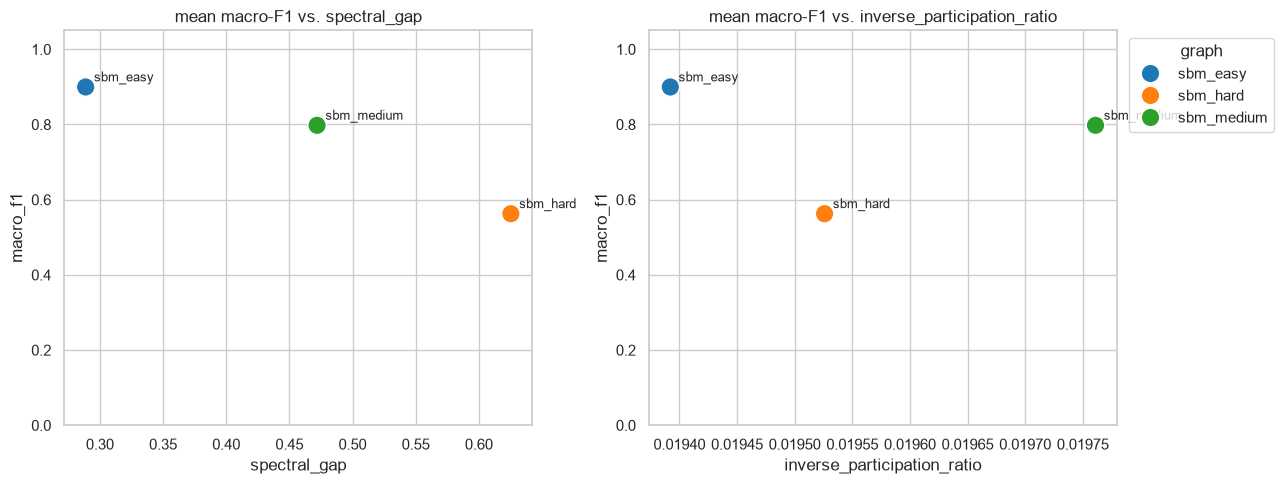

In [11]:
# Mean macro-F1 per graph vs. a connectivity metric (spectral gap) and a localization metric (IPR).
per_graph = (results.groupby("graph")["macro_f1"].mean()
             .to_frame("macro_f1").join(complexity))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["spectral_gap", "inverse_participation_ratio"]):
    sns.scatterplot(data=per_graph, x=metric, y="macro_f1", hue=per_graph.index,
                    s=180, ax=ax, legend=(ax is axes[1]))
    for g, r in per_graph.iterrows():
        ax.annotate(g, (r[metric], r["macro_f1"]), xytext=(6, 4),
                    textcoords="offset points", fontsize=9)
    ax.set_title(f"mean macro-F1 vs. {metric}")
    ax.set_ylim(0, 1.05)
if axes[1].get_legend():
    axes[1].legend(title="graph", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 7. Command-line interface

The same embedding is available as the `quvine` console script (installed with the
`[quvine]` extra), mirroring
`qprofiler` / `qsage`:

```bash
quvine --list-methods                                             # list all methods
quvine --edgelist edges.csv --method quvine_fused --output out/   # -> embedding.csv + meta.json
```

Integer node ids in the edge list are handled automatically (coerced to strings).

## Summary

In this tutorial you:

1. ✅ Generated three graphs of increasing difficulty (planted-community SBMs)
2. ✅ Embedded them with **12 methods** — quantum walks, quantum-calibrated filters/GAT/GraphGPS, and classical baselines — over **5 iterations**
3. ✅ Scored a **node-classification** task (macro-F1) for each
4. ✅ Summarized each graph's **complexity** (spectral gap, IPR, spectral degeneracy, entropy, …) with `evaluate_graph`
5. ✅ **Correlated** complexity with performance and visualized the trend

## See Also
- [QProfiler Tutorial](../QProfiler/example_qprofiler.ipynb) — the tabular-data analogue of this workflow
- `list_methods()` — the full QuVINE registry
- Fused embeddings: `embed(G, "quvine_fused")` combines all walk kinds